# Classification with Neural Networks in TensorFlow
Courtesy: https://github.com/mrdbourke

## How a deep neural network learns

A model learns by updating and improving its weights and biases every epoch (when we call the `fit()` function).

It does so by comparing the patterns its learned between the data and labels to the actual labels.

If the current patterns (weight matrices and bias values) don't result in a desirable decrease in the loss function (higher loss means worse predictions), the optimizer tries to steer the model to update its patterns in the right way (using the real labels as a reference).

This process of using the real labels as a reference to improve the model's predictions is called [**backpropagation**](https://en.wikipedia.org/wiki/Backpropagation).

In other words, data and labels pass through a model (**forward pass**) and it attempts to learn the relationship between the data and labels.

If this learned relationship isn't close to the actual relationship or it could be improved, the model does so by going back through itself (**backward pass**) and tweaking its weights and bias values to better represent the data.


## Import the Necessary Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#to scale the data using z-score
from sklearn.preprocessing import StandardScaler

#to split the dataset
from sklearn.model_selection import train_test_split

#Metrics to evaluate the model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#to ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [41]:
import tensorflow as tf
print(tf.__version__)

2.21.0


## Import and Prep the data for Modelling

In [42]:
#read the dataset
df = pd.read_csv('employee_attrition.csv')

In [43]:
# Separating target variable and other variables
Y = df['Attrition']
X = df.drop(columns=['Attrition'])

# Splitting the data
x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=1,
    stratify=Y
)

# Scaling the data
sc = StandardScaler()

X_scaled = sc.fit_transform(x_train)
X_test_scaled = sc.transform(x_test)

# TensorFlow가 잘 받도록 float32로 변환
X_scaled = X_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")



In [44]:
print(X_scaled.shape, X_scaled.dtype)
print(y_train.shape, y_train.dtype)
print(X_test_scaled.shape, X_test_scaled.dtype)
print(y_test.shape, y_test.dtype)

(2352, 57) float32
(2352,) float32
(588, 57) float32
(588,) float32


# Architecture of a classification neural network



| **Hyperparameter** | **Binary Classification** | **Multiclass classification** |
| --- | --- | --- |
| Input layer shape | Same as number of features (e.g. 5 for age, sex, height, weight, smoking status in heart disease prediction) | Same as binary classification |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited | Same as binary classification |
| Neurons per hidden layer | Problem specific, generally 10 to 100 | Same as binary classification |
| Output layer shape | 1 (one class or the other) | 1 per class (e.g. 3 for food, person or dog photo) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) | Same as binary classification |
| Output activation | [Sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) | [Softmax](https://en.wikipedia.org/wiki/Softmax_function) |
| Loss function | [Cross entropy](https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_loss_function_and_logistic_regression) ([`tf.keras.losses.BinaryCrossentropy`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy) in TensorFlow) | Cross entropy ([`tf.keras.losses.CategoricalCrossentropy`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy) in TensorFlow) |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) | Same as binary classification |


[**Sequential API**](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) - The Sequential API is the simplest and most straightforward way to build neural networks in TensorFlow. It allows you to create models layer by layer, where each layer is added in sequence.

* When using the Sequential API in TensorFlow, you don't need to specify the input layer or the number of neurons in the input layer. The input layer is automatically created based on the shape of the input data.

In [45]:
tf.keras.backend.clear_session()

model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(
    loss='binary_crossentropy',
    optimizer='sgd',
    metrics=['accuracy'],
    run_eagerly=True
)

print("before train_on_batch")

result = model_1.train_on_batch(X_scaled, y_train)

print("after train_on_batch")
print(result)

# 여기부터 추가

# predict() 대신 직접 계산
y_pred_prob = model_1(X_test_scaled, training=False).numpy()

y_pred = (y_pred_prob >= 0.5).astype("int32").ravel()

accuracy = (y_pred == y_test).mean()

print("Test accuracy:", accuracy)

before train_on_batch
after train_on_batch
[0.8491991758346558, 0.5250850319862366]
Test accuracy: 0.5017006802721088


Looking at the accuracy metric, our model performs poorly (54% accuracy on a binary classification problem is almost guessing). What if we trained it for longer?

# Improving a model


To improve a model, few ways you can tune the model:

1. Add more layers
2. Increase the number of neurons
3. Change the optimization function
4. Change the activation functions
5. Fit on more data
6. Fit for more epochs
7. Change the Learning rate

> You can think of the **learning rate** as how quickly a model learns. The higher the learning rate, the faster the model's capacity to learn, however, when the learning rate is too high, the model tries to learn too fast and doesn't learn anything.



## Model with more epochs

In [46]:
tf.keras.utils.set_random_seed(42)

# Train manually for 100 epochs

for epoch in range(100):

    result = model_1.train_on_batch(X_scaled, y_train)

print("Final train result:", result)

# Evaluate manually on training data

y_pred_prob = model_1(X_scaled, training=False).numpy()

y_pred = (y_pred_prob >= 0.5).astype("int32").ravel()

accuracy = (y_pred == y_train).mean()

print("Train accuracy:", accuracy)

Final train result: [0.7544052004814148, 0.5726409554481506]
Train accuracy: 0.6190476190476191


We can keep increasing the number of epochs and test for accuracy.

## Model with extra layer

In [47]:
# add an extra layer

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(
    loss='binary_crossentropy',
    optimizer='sgd',
    metrics=['accuracy'],
    run_eagerly=True
)

# fit() 대신 manual training
for epoch in range(100):
    result = model_1.train_on_batch(X_scaled, y_train)

print("Final train result:", result)

# evaluate() 대신 manual accuracy
y_pred_prob = model_1(X_scaled, training=False).numpy()
y_pred = (y_pred_prob >= 0.5).astype("int32").ravel()

accuracy = (y_pred == y_train).mean()
print("Train accuracy:", accuracy)

Final train result: [0.8329372406005859, 0.5956590175628662]
Train accuracy: 0.7062074829931972


## Model with more Neurons

Let's add neurons in the hidden layer

In [48]:
# set a fixed random seed for the model's weight initialization
tf.keras.utils.set_random_seed(42)

# set model_1 to None
model_1 = None

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile the model
model_1.compile(
    loss='binary_crossentropy',
    optimizer='sgd',
    metrics=['accuracy'],
    run_eagerly=True
)

# 3. Train manually
for epoch in range(100):
    result = model_1.train_on_batch(X_scaled, y_train)

print("Final train result:", result)

# 4. Manual evaluation
y_pred_prob = model_1(X_scaled, training=False).numpy()

y_pred = (y_pred_prob >= 0.5).astype("int32").ravel()

accuracy = (y_pred == y_train).mean()

print("Train accuracy:", accuracy)

Final train result: [0.7148438096046448, 0.6026232838630676]
Train accuracy: 0.6926020408163265


Adding more neurons to a hidden layer can sometimes decrease the accuracy of a model due to **overfitting**. Keep the neuron 3 and add new layer with 1 neuron.

In [49]:
# set a fixed random seed for the model's weight initialization
tf.keras.utils.set_random_seed(42)

# set model_1 to None
model_1 = None

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile the model
model_1.compile(
    loss='binary_crossentropy',
    optimizer='sgd',
    metrics=['accuracy'],
    run_eagerly=True
)

# 3. Train manually
for epoch in range(100):
    result = model_1.train_on_batch(X_scaled, y_train)

print("Final train result:", result)

# 4. Manual evaluation
y_pred_prob = model_1(X_scaled, training=False).numpy()

y_pred = (y_pred_prob >= 0.5).astype("int32").ravel()

accuracy = (y_pred == y_train).mean()

print("Train accuracy:", accuracy)

Final train result: [0.6891039609909058, 0.6329889297485352]
Train accuracy: 0.7385204081632653


## Model with new Learning Rate
Read more about Learning Rate here: [Learning rate explained](https://medium.com/@swapnilin/learning-rate-hyperparameter-explained-2c1a619cbd33)

In [50]:
# The learning rate. Defaults to 0.001

# set a fixed random seed for the model's weight initialization
tf.keras.utils.set_random_seed(42)

# set model_1 to None
model_1 = None

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile the model
model_1.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy'],
    run_eagerly=True
)

# 3. Train manually
for epoch in range(100):
    result = model_1.train_on_batch(X_scaled, y_train)

print("Final train result:", result)

# 4. Manual evaluation
y_pred_prob = model_1(X_scaled, training=False).numpy()

y_pred = (y_pred_prob >= 0.5).astype("int32").ravel()

accuracy = (y_pred == y_train).mean()

print("Train accuracy:", accuracy)

Final train result: [0.7148438096046448, 0.6026232838630676]
Train accuracy: 0.6926020408163265


By increasing the learning rate a little, we improved the accuracy to 85%

## Finding the best learning rate

Aside from the architecture itself (the layers, number of neurons, activations, etc), the most important hyperparameter you can tune for your neural network models is the **learning rate**.

We changed the SGD optimizer's learning rate from the default of `0.001` to `0.0011`

To find the optimal learning rate we're going to use the following:

* A [learning rate **callback**](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/LearningRateScheduler) - You can think of a callback as an extra piece of functionality you can add to your model *while* its training.


> **Note:** The default hyperparameters of many neural network building blocks in TensorFlow are setup in a way which usually work best with default values for most datasets.

In [51]:
# set a fixed random seed for the model's weight initialization
tf.keras.utils.set_random_seed(42)

model_1 = None

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile the model
model_1.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"],
    run_eagerly=True
)

# 3. Manual learning-rate schedule training
losses = []
lrs = []

for epoch in range(100):
    lr = 0.001 * 0.9**(epoch / 3)

    model_1.optimizer.learning_rate.assign(lr)

    loss, acc = model_1.train_on_batch(X_scaled, y_train)

    losses.append(loss)
    lrs.append(lr)

print("Final LR:", lr)
print("Final loss:", loss)
print("Final accuracy:", acc)

# 4. Manual evaluation
y_pred_prob = model_1(X_scaled, training=False).numpy()

y_pred = (y_pred_prob >= 0.5).astype("int32").ravel()

accuracy = (y_pred == y_train).mean()

print("Train accuracy:", accuracy)


Final LR: 3.090315438263264e-05
Final loss: 0.9110963940620422
Final accuracy: 0.5067304372787476
Train accuracy: 0.5085034013605442


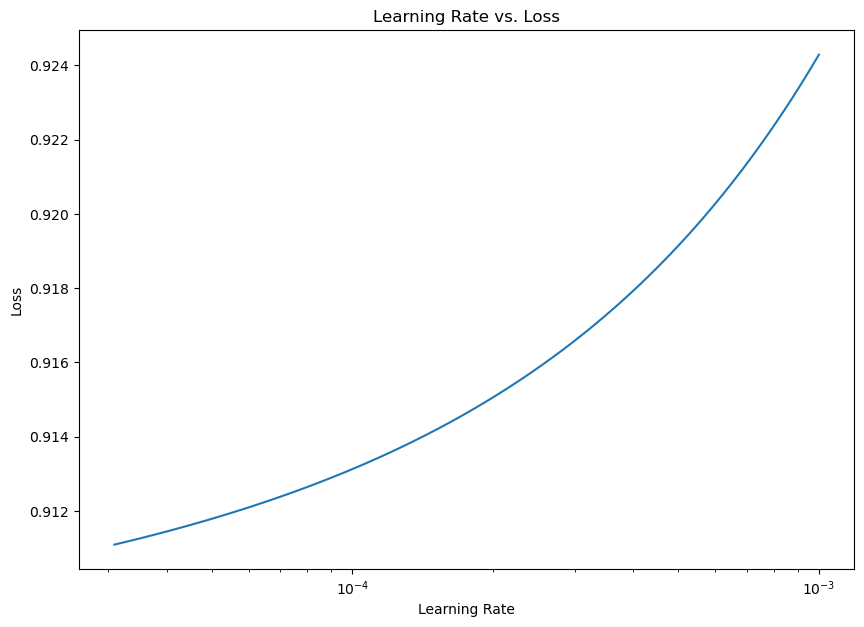

In [52]:

# Plot the learning rate versus the loss
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, losses)
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs. Loss")
plt.show()

The ideal learning rate ends up somewhere near 0.001

## Activation Functions
Read more about Activation functions here : [Activation functions explained](https://medium.com/towards-data-science/using-activation-functions-in-neural-nets-c119ad80826)

In [68]:
# set a fixed random seed for the model's weight initialization
tf.keras.utils.set_random_seed(42)

# set model_1 to None
model_1 = None

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(3),  # LeakyReLU, sigmoid, relu, tanh 등 실험 가능
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile the model
model_1.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy'],
    run_eagerly=True
)

# 3. Manual training
for epoch in range(100):
    loss, acc = model_1.train_on_batch(X_scaled, y_train)

print("Final loss:", loss)
print("Final accuracy:", acc)

# 4. Manual evaluation
y_pred_prob = model_1(X_scaled, training=False).numpy()

y_pred = (y_pred_prob >= 0.5).astype("int32").ravel()

accuracy = (y_pred == y_train).mean()

print("Train accuracy:", accuracy)


Final loss: 0.7148438096046448
Final accuracy: 0.6026232838630676
Train accuracy: 0.6926020408163265


In [69]:
# Predict on test set and view first 3 values
y_preds = model_1(X_test_scaled, training=False).numpy()

y_preds[:3]

array([[0.15877716],
       [0.8728669 ],
       [0.6599434 ]], dtype=float32)

It looks like we need to get our predictions into the binary format (0 or 1). Currently, they are prediction probabilities.

In [70]:
y_preds = tf.round(
    model_1(X_test_scaled, training=False)
)

y_preds[:3]

<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
array([[0.],
       [1.],
       [1.]], dtype=float32)>

In [71]:
# Evaluate the test predictions
accuracy_score(y_test, y_preds)

0.6887755102040817

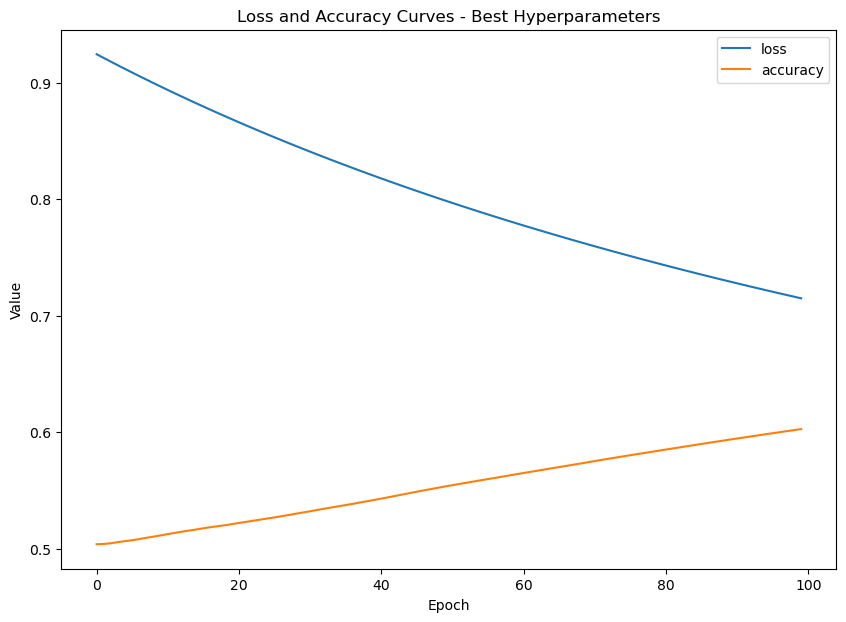

In [75]:
losses = []
accuracies = []

tf.keras.utils.set_random_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy'],
    run_eagerly=True
)

for epoch in range(100):
    loss, acc = model_1.train_on_batch(X_scaled, y_train)
    losses.append(loss)
    accuracies.append(acc)

pd.DataFrame({
    "loss": losses,
    "accuracy": accuracies
}).plot(figsize=(10, 7))

plt.title("Loss and Accuracy Curves - Best Hyperparameters")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.show()

## More classification evaluation methods

There are a number of different evaluation metrics we can use to evaluate our classification models.

| **Metric name/Evaluation method** | **Defintion** | **Code** |
| --- | --- | --- |
| Accuracy | Out of 100 predictions, how many does your model get correct? E.g. 95% accuracy means it gets 95/100 predictions correct. | [`sklearn.metrics.accuracy_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) or [`tf.keras.metrics.Accuracy()`](tensorflow.org/api_docs/python/tf/keras/metrics/Accuracy) |
| Precision | Proportion of true positives over total number of samples. Higher precision leads to less false positives (model predicts 1 when it should've been 0). | [`sklearn.metrics.precision_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html) or [`tf.keras.metrics.Precision()`](tensorflow.org/api_docs/python/tf/keras/metrics/Precision) |
| Recall | Proportion of true positives over total number of true positives and false negatives (model predicts 0 when it should've been 1). Higher recall leads to less false negatives. | [`sklearn.metrics.recall_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) or [`tf.keras.metrics.Recall()`](tensorflow.org/api_docs/python/tf/keras/metrics/Recall) |
| F1-score | Combines precision and recall into one metric. 1 is best, 0 is worst. | [`sklearn.metrics.f1_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) |
| [Confusion matrix](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/)  | Compares the predicted values with the true values in a tabular way, if 100% correct, all values in the matrix will be top left to bottom right (diagnol line). | Custom function or [`sklearn.metrics.plot_confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html) |
| Classification report | Collection of some of the main classification metrics such as precision, recall and f1-score. | [`sklearn.metrics.classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) |



# Plot the loss curves

Looking at the plots above, we can see the outputs of our model are very good.

But how did our model go whilst it was learning?

As in, how did the performance change everytime the model had a chance to look at the data (once every epoch)?

To figure this out, we can check the **loss curves** (also referred to as the **learning curves**).

You might've seen we've been using the variable `history` when calling the `fit()` function on a model ([`fit()` returns a `History` object](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit)).

This is where we'll get the information for how our model is performing as it learns.


Inspecting the outputs, we can see the loss values going down and the accuracy going up.

How's it look (visualize, visualize, visualize)?

Beautiful. This is the ideal plot we'd be looking for when dealing with a classification problem, loss going down, accuracy going up.

> **Note:** The loss function going down means the model is improving (the predictions it's making are getting closer to the ground truth labels).

<Axes: >

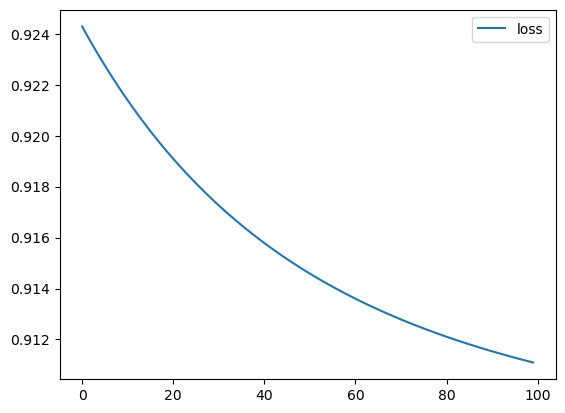

In [57]:
pd.DataFrame({
    "loss": losses
}).plot()

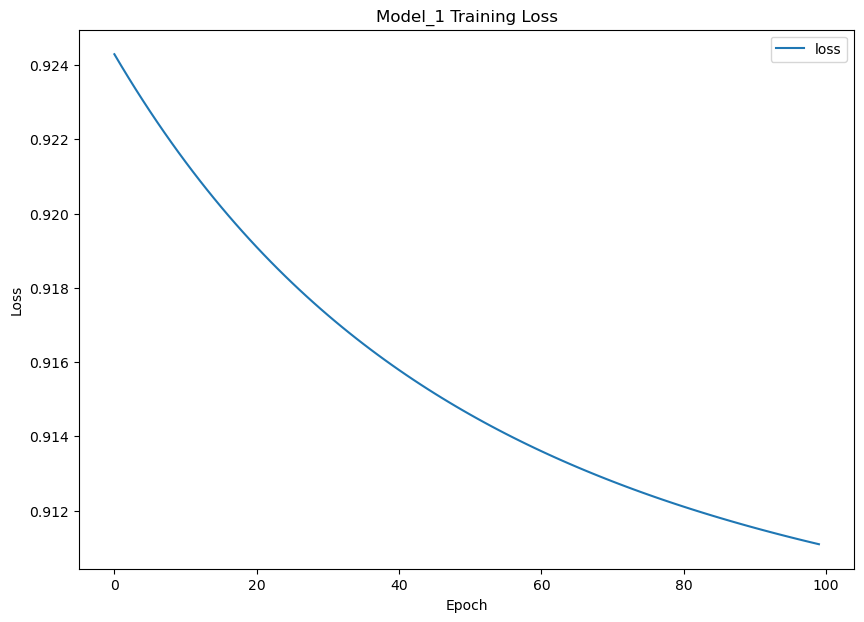

In [58]:
pd.DataFrame({
    "loss": losses
}).plot(figsize=(10,7))

plt.title("Model_1 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## TensorFlow Workaround for Environment Compatibility
made by DHWON


Due to TensorFlow execution issues in the local environment, several standard Keras methods were replaced with equivalent alternatives.

| Standard Keras Method | Alternative Implementation |
|----------------------|---------------------------|
| `model.fit()` | `model.train_on_batch()` |
| `model.evaluate()` | Manual accuracy calculation |
| `model.predict()` | `model(X, training=False).numpy()` |
| `history.history["loss"]` | `losses` list |
| `history.history["accuracy"]` | `accuracies` list |

### Manual Training Example

```python
losses = []
accuracies = []

for epoch in range(100):
    loss, acc = model.train_on_batch(X_scaled, y_train)

    losses.append(loss)
    accuracies.append(acc)

### TensorFlow Compatibility Note

The original implementation used Keras high-level methods (`fit`, `evaluate`, and `predict`). However, in the local TensorFlow 2.21 environment running on Apple Silicon, these methods became unresponsive during execution.

To complete the analysis, equivalent low-level TensorFlow operations were used instead:

- `model.fit()` → `model.train_on_batch()`
- `model.predict()` → `model(X, training=False).numpy()`
- `model.evaluate()` → manual accuracy calculation

This workaround preserves the model training and evaluation process while avoiding environment-specific execution issues.

In [59]:
best_model_table = pd.DataFrame({
    "Hyperparameter": [
        "Model architecture",
        "Hidden layer neurons",
        "Hidden activation",
        "Output activation",
        "Loss function",
        "Optimizer",
        "Learning rate",
        "Epochs",
        "Batch size",
        "Training method",
        "Train accuracy",
        "Test accuracy"
    ],
    "Best value achieved": [
        "Dense(3) + Dense(1)",
        "3",
        "Linear",
        "Sigmoid",
        "Binary Crossentropy",
        "SGD",
        "0.01",
        "100",
        "32",
        "train_on_batch()",
        "0.6926",
        "0.6888"
    ]
})

best_model_table

,Hyperparameter,Best value achieved
0,Model architecture,Dense(3) + Dense(1)
1,Hidden layer neurons,3
2,Hidden activation,Linear
3,Output activation,Sigmoid
4,Loss function,Binary Crossentropy
5,Optimizer,SGD
6,Learning rate,0.01
7,Epochs,100
8,Batch size,32
9,Training method,train_on_batch()
